### Image Stitching

In this notebook we are going to demonstrate how feature detection and feature descriptors can help us to perform image stitching (in this case, to compose a panoramic view from 2 images). Let's start with the usual imports.

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

We will be working with 2 images that capture the same scene but with **different camera position and different time**. The objective is to transform the source image to align with the target image. In other words, we want to find the homography that transforms the source view into the target view and use this homography to stitch the two images together.

(<Axes: title={'center': 'Target'}>,
 Text(0.5, 1.0, 'Target'))

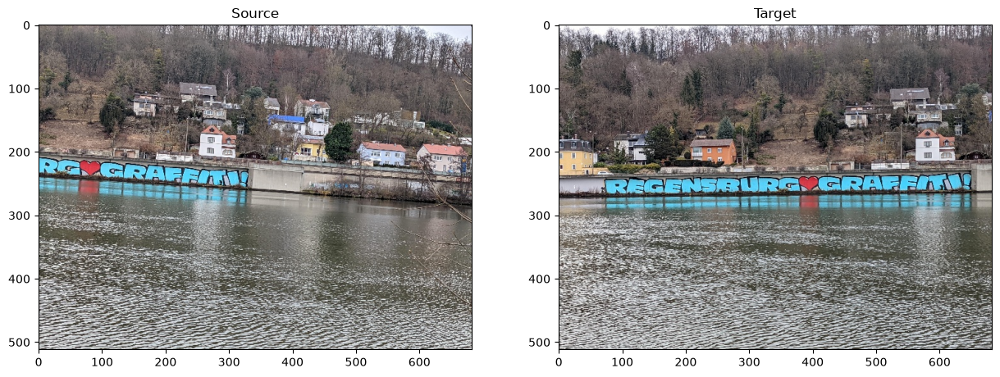

In [3]:
# Load source view
img_src = cv2.imread('../data/image3_res.jpg')
img_src = cv2.cvtColor(img_src, cv2.COLOR_BGR2RGB)

# Load target view
img_dst = cv2.imread('../data/image2_res.jpg')
img_dst = cv2.cvtColor(img_dst, cv2.COLOR_BGR2RGB)

plt.subplot(121), plt.imshow(img_src), plt.title('Source')
plt.subplot(122), plt.imshow(img_dst), plt.title('Target')

### Feature Detection

In order to find the abovementioned homography, we need to find the pixel correspondences. To do so, we will be using the well-known SIFT features (you can use any detector + descriptor you want).

(<Axes: title={'center': 'Target'}>,
 Text(0.5, 1.0, 'Target'))

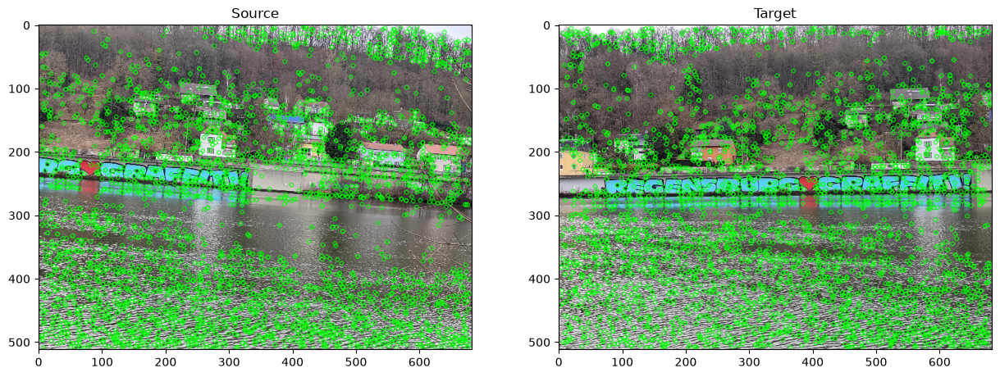

In [4]:
# Let's create the SIFT detector
descriptor = cv2.SIFT_create()

# We don't want to use any pixel mask, so we set it to None
(kps_src, features_src) = descriptor.detectAndCompute(img_src, None)
(kps_dst, features_dst) = descriptor.detectAndCompute(img_dst, None)

# Let's draw the detected features
feats_img_src = cv2.drawKeypoints(img_src, kps_src, None, color=(0,255,0))
feats_img_dst = cv2.drawKeypoints(img_dst, kps_dst, None, color=(0,255,0))

plt.subplot(121), plt.imshow(feats_img_src), plt.title('Source')
plt.subplot(122), plt.imshow(feats_img_dst), plt.title('Target')

We see there is **a lot** of detected features and many of them are not relevant to our task (e.g. the waves on the river surface).

### Feature Matching

Given the two sets of source and target features, we need to find the correspondences, i.e., for each feature on the source image we need to find the best matching feature on the target image. The naive approach is to match every source feature to its nearest neighbor (in descriptor space) on the target image, but this alone produces a lot of wrong matches. In this notebook, we will be using the **brute-force matcher with cross-check**: a candidate match (i, j) is only kept if feature j is the nearest neighbor of feature i **and** feature i is, in turn, the nearest neighbor of feature j. This mutual-agreement constraint discards a good chunk of the spurious matches before we even get to RANSAC.

In [5]:
# Brute-force matcher with cross-check
# Note: Euclidean norm, as the distance metric for feature descriptors, is suitable for SIFT,
# but not necessarily for other descriptors.
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(features_src, features_dst)

# Sort the features in order of distance (merely for plotting purposes)
matches = sorted(matches, key = lambda x:x.distance)

# Show how many features we had originally and how many matches we found
print("Num features:", len(features_src), len(features_dst))
print("Num matches :", len(matches))

Num features: 3863 3977
Num matches : 1374


As you can see, the cross-check already took care and eliminated many of the irrelevant features (both on source and target side).

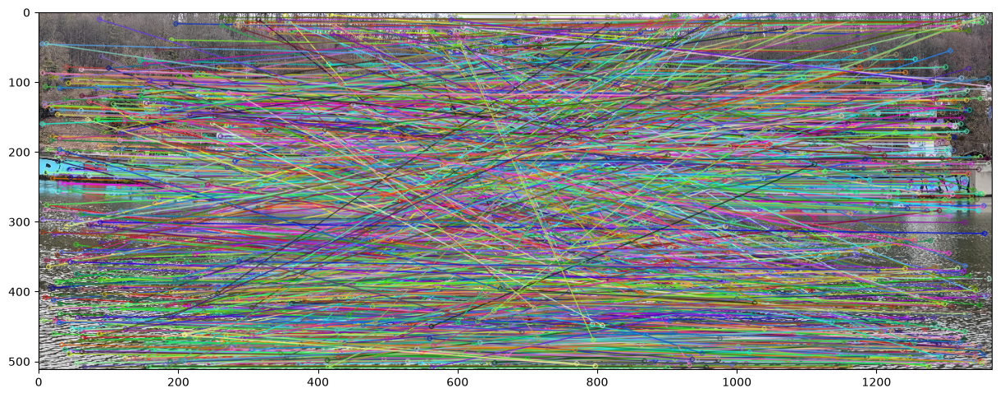

In [6]:
# Let's now draw the found matches (correspondences)
result = cv2.drawMatches(img_src, kps_src, img_dst, kps_dst, matches,
                         None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(result)

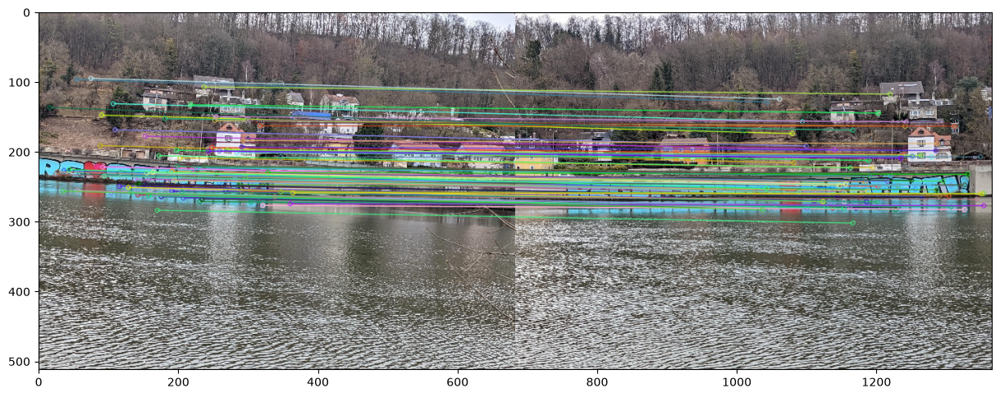

In [7]:
# Let's now draw the best fitting matches (correspondences)
result = cv2.drawMatches(img_src, kps_src, img_dst, kps_dst, matches[:100],
                         None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(result)

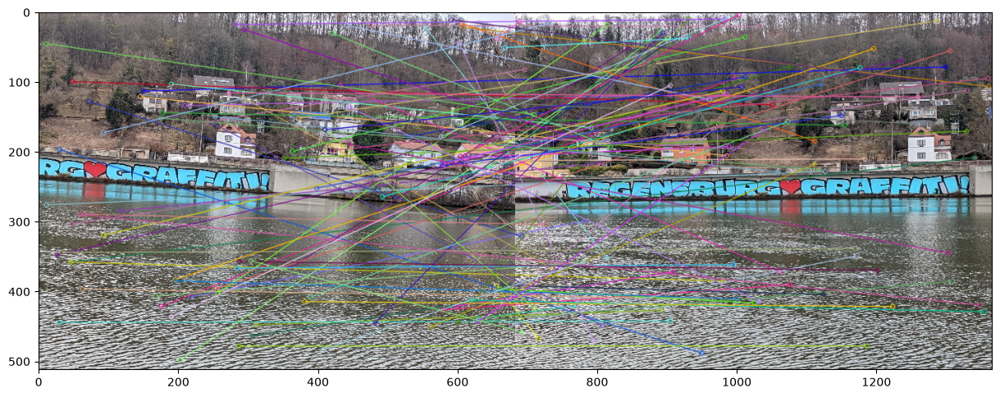

In [8]:
# Let's now draw the least fitting matches (correspondences)
result = cv2.drawMatches(img_src, kps_src, img_dst, kps_dst, matches[-100:],
                         None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(result)

Notice how many of these worst-100 matches look implausible (e.g. connecting the river/wave texture on one image to unrelated locations on the other) — these are exactly the kind of **outliers** that would badly skew a naive least-squares fit. This is the problem RANSAC is designed to solve.

Given the correspondences (i.e. the set of source points and the set of target points) we are going to find the best fitting homography transform. Each correspondence gives us 2 equations, and the homography has 8 degrees of freedom (9 matrix entries, but the scale is normalized away), so in theory 4 correspondences are enough to solve for it exactly. In practice we have far more than 4, many of them noisy or plain wrong (see the outliers above), so OpenCV instead minimizes a mean-square reprojection error over all the inliers it finds. We will also switch the RANSAC on since this is a **powerful tool** to eliminate outliers: it repeatedly samples 4 random correspondences, fits a homography from them, and counts how many of the remaining correspondences agree with it (i.e. reproject within `ransacReprojThreshold` pixels — here 4) before keeping the homography with the largest such consensus set.

In [9]:
# Convert keypoints to numpy arrays
kps_src = np.float32([kp.pt for kp in kps_src])
kps_dst = np.float32([kp.pt for kp in kps_dst])

# Construct the two sets of points (source and target)
pts_src = np.float32([kps_src[m.queryIdx] for m in matches])
pts_dst = np.float32([kps_dst[m.trainIdx] for m in matches])

# Estimate homography between source and target (try to see what happens if we switch RANSAC off)
(H, status) = cv2.findHomography(pts_src, pts_dst, cv2.RANSAC, 4)

print('Homography matrix:')
print(H)

Homography matrix:
[[ 7.68348215e-01  4.91859864e-02  3.05462290e+02]
 [-1.60498308e-01  9.17608179e-01  4.66088989e+01]
 [-3.36606022e-04 -4.25349209e-05  1.00000000e+00]]


Let's actually check what happens if we switch RANSAC off, i.e. if we fit the homography with a plain least-squares method that uses **every** correspondence, outliers included.

(<Axes: title={'center': 'Source warped without RANSAC (all matches)'}>,
 Text(0.5, 1.0, 'Source warped without RANSAC (all matches)'))

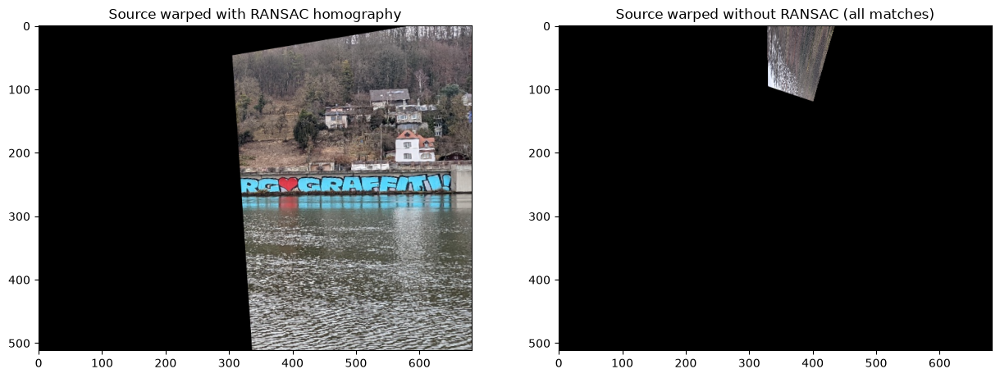

In [10]:
# Plain least-squares fit, no outlier rejection
(H_no_ransac, _) = cv2.findHomography(pts_src, pts_dst, 0)

h, w = img_dst.shape[:2]
warped_ransac = cv2.warpPerspective(img_src, H, (w, h))
warped_no_ransac = cv2.warpPerspective(img_src, H_no_ransac, (w, h))

plt.subplot(121), plt.imshow(warped_ransac), plt.title('Source warped with RANSAC homography')
plt.subplot(122), plt.imshow(warped_no_ransac), plt.title('Source warped without RANSAC (all matches)')

### Image Stitching

Using the estimated homography, we are going to transform the source image to the target viewport and we will stitch the two images together.

(<matplotlib.image.AxesImage at 0x7d2ce3e8f950>,
 (np.float64(-0.5), np.float64(1365.5), np.float64(1023.5), np.float64(-0.5)))

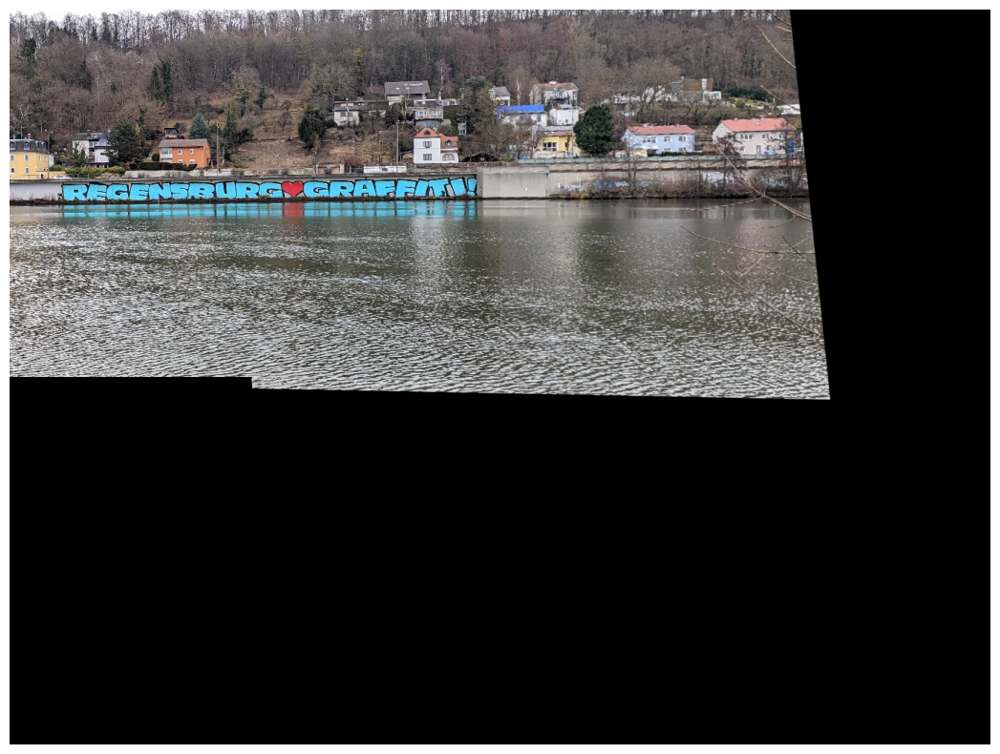

In [11]:
# Prepare canvas
width = img_src.shape[1] + img_src.shape[1]
height = img_src.shape[0] + img_src.shape[0]

# Generate the stitched image
result = cv2.warpPerspective(img_src, H, (width, height))
result[0:img_dst.shape[0], 0:img_dst.shape[1]] = img_dst

plt.imshow(result), plt.axis('off')

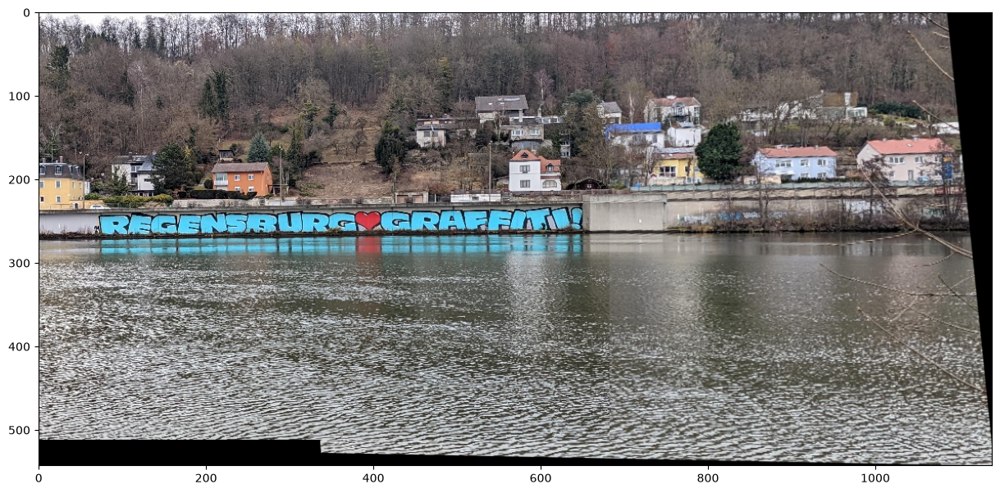

In [12]:
# Remove the unnecessary black filling.
# Summing over channels turns any pure-black canvas pixel into a 0; for each row/column we find
# where the first such 0 appears, and crop the canvas at the furthest of those positions so we
# keep all the stitched content and only drop the empty margins.
contour = np.sum(result, axis=-1)
bottom = np.max(np.argmin(contour, axis=0))
right = np.max(np.argmin(contour, axis=1))

# Final result
result = result[0:bottom, 0:right, :]
plt.imshow(result)

(<Axes: title={'center': 'Panorama'}>,
 Text(0.5, 1.0, 'Panorama'))

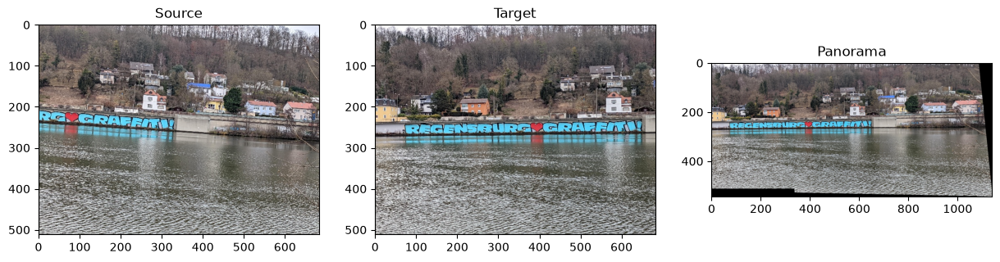

In [13]:
# Let's plot the three images together for better comparison
plt.subplot(131), plt.imshow(img_src), plt.title('Source')
plt.subplot(132), plt.imshow(img_dst), plt.title('Target')
plt.subplot(133), plt.imshow(result), plt.title('Panorama')